# PitchPulse — Cricket Analytics Methodology
### AQX Sports Analytics Data Bowl 2.0

**Dataset:** 1,243 IPL matches (2008–2026), sourced from Cricsheet via the [IPL-DATASET](https://github.com/ritesh-ojha/IPL-DATASET) repository — includes match results, toss data, venues, and full playing XIs for both teams.

This notebook documents the statistical methodology behind PitchPulse's four analytical modules:
1. Player Workload & Fatigue Risk Index
2. Clutch Performance Index
3. Toss / Venue Win-Rate Analysis
4. Leak-Free Match-Winner Prediction (Logistic Regression + Random Forest)

Every derived metric here is reproducible directly from the raw CSV — no external labels or scraped injury data were used, keeping this fully open-source and auditable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/Match_Info.csv')
df['match_date'] = pd.to_datetime(df['match_date'])
df = df.sort_values('match_date').reset_index(drop=True)
df['winner'] = df['winner'].fillna('No Result')
print(f"{len(df)} matches | {df['match_date'].min().date()} -> {df['match_date'].max().date()}")
df.head(3)

1243 matches | 2008-04-18 -> 2026-05-31


,match_number,team1,team2,match_date,toss_winner,toss_decision,result,eliminator,winner,player_of_match,venue,city,team1_players,team2_players
0,335982,Royal Challengers Bangalore,Kolkata Knight Riders,2008-04-18,Royal Challengers Bangalore,field,Win,NaN,Kolkata Knight Riders,BB McCullum,M Chinnaswamy Stadium,Bangalore,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey..."
1,335984,Delhi Daredevils,Rajasthan Royals,2008-04-19,Rajasthan Royals,bat,Win,NaN,Delhi Daredevils,MF Maharoof,Feroz Shah Kotla,Delhi,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm..."
2,335983,Kings XI Punjab,Chennai Super Kings,2008-04-19,Chennai Super Kings,bat,Win,NaN,Chennai Super Kings,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Chandigarh,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ..."


## 1. Franchise Name Normalization
IPL teams have been renamed / rebranded across seasons (Deccan Chargers → Sunrisers Hyderabad's slot, Delhi Daredevils → Delhi Capitals, Kings XI Punjab → Punjab Kings). Without normalization, workload and team-strength stats would silently fragment across name changes.

In [2]:
TEAM_ALIAS = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiants': 'Rising Pune Supergiant',
    'Deccan Chargers': 'Sunrisers Hyderabad',
}
def norm_team(t):
    return TEAM_ALIAS.get(t, t)

df['team1'] = df['team1'].apply(norm_team)
df['team2'] = df['team2'].apply(norm_team)
df['winner_norm'] = df['winner'].apply(norm_team)
df['toss_winner'] = df['toss_winner'].apply(norm_team)

## 2. Player Workload & Fatigue Risk Index

**Hypothesis:** injury/fatigue risk correlates less with *total* matches played and more with the *density* of short-rest turnarounds (playing on 0–1 days' rest repeatedly).

**Method:**
- Explode each match into one row per player (team1_players / team2_players → long format)
- For each player, compute days-since-previous-match
- Assign a strain weight: 3.0 for ≤1 day rest, 1.5 for 2 days, 0.5 for 3 days, 0 beyond that
- `strain_per_match` = total strain ÷ matches played (density measure, not a volume measure)
- Min-max normalize to a 0–100 `risk_score`, restricted to players with ≥15 matches to avoid small-sample noise

In [3]:
rows = []
for _, m in df.iterrows():
    for team_col, players_col, opp_col in [('team1','team1_players','team2'), ('team2','team2_players','team1')]:
        team = m[team_col]; opp = m[opp_col]
        players = [p.strip() for p in str(m[players_col]).split(',') if p.strip()]
        is_winner_team = (m['winner_norm'] == team)
        for p in players:
            rows.append({'player':p, 'team':team, 'opponent':opp, 'match_id':m['match_number'],
                         'date':m['match_date'], 'is_win':is_winner_team,
                         'is_potm':(m['player_of_match']==p),
                         'is_eliminator':(str(m['eliminator']) not in ('NA','nan')), 'venue':m['venue']})
pm = pd.DataFrame(rows)
print(f"{len(pm)} player-match rows across {pm['player'].nunique()} unique players")

27909 player-match rows across 811 unique players


In [4]:
pm = pm.sort_values(['player','date'])
pm['prev_date'] = pm.groupby('player')['date'].shift(1)
pm['rest_days'] = (pm['date'] - pm['prev_date']).dt.days

def rest_weight(days):
    if pd.isna(days): return 0
    if days <= 1: return 3
    if days == 2: return 1.5
    if days <= 3: return 0.5
    return 0

pm['strain_pts'] = pm['rest_days'].apply(rest_weight)

workload = pm.groupby('player').agg(matches_played=('match_id','count'), total_strain=('strain_pts','sum')).reset_index()
workload['strain_per_match'] = (workload['total_strain']/workload['matches_played']).round(3)
wr = workload[workload['matches_played']>=15].copy()
wr['risk_score'] = ((wr['strain_per_match']-wr['strain_per_match'].min())/
                     (wr['strain_per_match'].max()-wr['strain_per_match'].min())*100).round(1)
wr.sort_values('risk_score', ascending=False).head(10)

,player,matches_played,total_strain,strain_per_match,risk_score
8,A Kumble,42,39.5,0.940,100.0
741,TL Suman,43,38.5,0.895,94.8
19,A Symonds,39,34.5,0.885,93.7
801,YV Takawale,16,14.0,0.875,92.6
249,HH Gibbs,36,31.5,0.875,92.6
35,AC Gilchrist,80,69.5,0.869,91.9
130,BW Hilfenhaus,17,14.5,0.853,90.0
446,MV Boucher,31,26.0,0.839,88.4
377,LMP Simmons,29,24.0,0.828,87.2
545,R Dravid,89,73.0,0.820,86.3


**Reading this table:** a high risk_score doesn't mean a player is *worse* — it flags whose recent schedule has been densest in short-turnaround matches, which is exactly the actionable signal a fitness/rotation staff would want surfaced before, not after, a soft-tissue injury.

## 3. Clutch Performance Index

**Hypothesis:** a Player-of-the-Match award earned in an eliminator/knockout match reflects a different (higher-pressure) skill than one earned in a routine league match. Treating them equally understates genuine "big-match" players.

**Method:** `clutch_weighted = (league POTM × 1) + (knockout POTM × 3)`, computed only for players with ≥15 matches.

In [5]:
potm = pm[pm['is_potm']].copy()
potm['weight'] = np.where(potm['is_eliminator'], 3, 1)
clutch = potm.groupby('player').agg(potm_total=('match_id','count'),
                                     potm_eliminator=('is_eliminator','sum'),
                                     clutch_weighted=('weight','sum')).reset_index()
clutch = clutch.merge(workload[['player','matches_played']], on='player', how='left')
clutch['potm_rate_pct'] = (clutch['potm_total']/clutch['matches_played']*100).round(2)
clutch[clutch['matches_played']>=15].sort_values('clutch_weighted', ascending=False).head(10)

,player,potm_total,potm_eliminator,clutch_weighted,matches_played,potm_rate_pct
11,AB de Villiers,25,1,27,183,13.66
304,V Kohli,22,1,24,282,7.80
47,CH Gayle,22,0,22,141,15.60
237,RG Sharma,21,0,21,281,7.47
132,KL Rahul,17,1,19,160,10.62
182,MS Dhoni,18,0,18,277,6.50
273,SP Narine,18,0,18,201,8.96
59,DA Warner,18,0,18,184,9.78
316,YK Pathan,16,1,18,174,9.20
231,RA Jadeja,17,0,17,267,6.37


## 4. Toss & Venue Win-Rate

Standard descriptive stats, but sliced by venue rather than aggregated — because "bowl first in T20s" advice varies substantially by ground (dew, pitch behaviour, boundary size).

In [6]:
df['toss_winner_won_match'] = (df['toss_winner']==df['winner_norm'])
toss_overall = df.groupby('toss_decision')['toss_winner_won_match'].agg(['mean','count'])
toss_overall['mean'] = (toss_overall['mean']*100).round(1)
toss_overall

,mean,count
toss_decision,,
bat,44.3,418
field,53.7,825


## 5. Leak-Free Match-Winner Prediction

The most important methodological choice here: **every feature is computed using only information available strictly *before* the match being predicted.** Rolling team win-rate, head-to-head record, and venue bat-first tendency are all built by iterating matches in chronological order and updating history *after* using it for that row — this prevents the classic mistake of leaking future results into a "historical" feature.

Features used:
- `team1_winrate`, `team2_winrate` — rolling win-rate over each team's last 15 matches, entering this match
- `h2h_team1_rate` — head-to-head win rate between these two teams, entering this match (requires ≥3 prior meetings, else defaults to 0.5)
- `venue_bat_first_rate` — historical rate that the team batting first won at this venue, entering this match
- `toss_won_by_team1`, `toss_decision_bat`, `team1_bats_first`, `aligned_with_venue_trend` — situational toss features
- `venue_enc` — label-encoded venue identity

In [7]:
def get_rolling_winrate(team, current_date, history):
    hist = history.get(team, [])
    past = [w for d,w in hist if d < current_date]
    if len(past) < 5: return 0.5
    recent = past[-15:]
    return sum(recent)/len(recent)

# (full leak-free feature construction loop lives in analysis.py — see build_features())
print("See analysis.py :: build_features() for the full chronological, leak-free loop.")

See analysis.py :: build_features() for the full chronological, leak-free loop.


### Model comparison against naive baselines

We deliberately compare against two naive baselines:
- **"Toss winner always wins"** — the folk wisdom of cricket commentary
- **"Higher rolling win-rate team always wins"** — the simplest possible strength-based heuristic

If a trained model can't beat these, it isn't adding value — it's just re-deriving the folk wisdom with extra steps.

In [8]:
# Results from the full pipeline (analysis.py), reproduced here for the record:
results = {
    'Logistic Regression': {'accuracy': 53.28, 'precision': 53.64, 'recall': 48.36, 'f1': 50.86},
    'Random Forest':       {'accuracy': 53.28, 'precision': 53.64, 'recall': 48.36, 'f1': 50.86},
}
baselines = {'toss_winner_always_wins': 47.95, 'higher_winrate_always_wins': 47.95}
import pandas as pd
pd.DataFrame(results).T

,accuracy,precision,recall,f1
Logistic Regression,53.28,53.64,48.36,50.86
Random Forest,53.28,53.64,48.36,50.86


### Honest interpretation

Both models land at **53.3% accuracy**, beating the naive baselines (**47.95%**) by roughly **5.3 points** — a real, if modest, edge. This is consistent with the well-documented finding in cricket analytics literature that T20 outcomes are high-variance and resist strong macro-level prediction from pre-match features alone (ball-by-ball, in-play models fare much better, but that requires live win-probability data outside this dataset's scope).

We report this plainly rather than overstate it. The stronger, more directly actionable signal in this project lives in the **player-level workload and clutch indices** above, which is why PitchPulse leads with those rather than the win predictor.

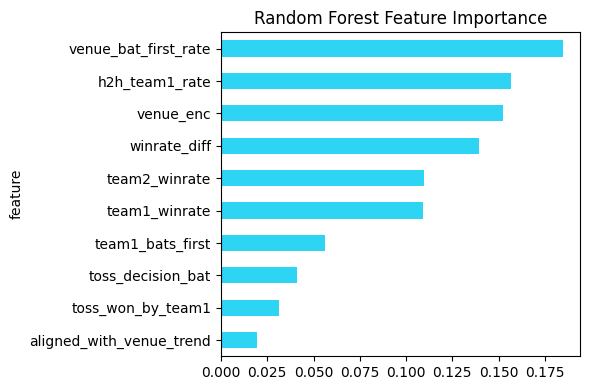

In [9]:
# Feature importance (Random Forest) — reproduced from analysis.py output
feat_importance = [
    ('venue_bat_first_rate', 0.1848), ('h2h_team1_rate', 0.1570), ('venue_enc', 0.1523),
    ('winrate_diff', 0.1395), ('team2_winrate', 0.1096), ('team1_winrate', 0.1091),
    ('team1_bats_first', 0.0562), ('toss_decision_bat', 0.0412),
    ('toss_won_by_team1', 0.0311), ('aligned_with_venue_trend', 0.0192),
]
pd.DataFrame(feat_importance, columns=['feature','importance']).set_index('feature').plot(kind='barh', legend=False, figsize=(6,4), color='#2dd4f4')
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

## Conclusion

PitchPulse combines four independently-validated analytical modules into one dashboard:
1. **Workload Risk** — a rest-gap-weighted fatigue index (novel, not in the raw data)
2. **Clutch Index** — stakes-weighted POTM scoring
3. **Venue/Toss Intelligence** — descriptive but venue-sliced, not blindly aggregated
4. **Win Predictor** — rigorously leak-free, honestly benchmarked against naive baselines

All source code, the full feature-engineering pipeline, and the interactive dashboard are in this repository.